### Interpretation Study on Attention on CODI 

In [1]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [56]:

import torch 
import transformers 

import numpy as np 
from pathlib import Path 
from torch.utils.data import Dataset
from typing import Dict, Sequence
from dataclasses import dataclass
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt 
import pandas as pd 
import csv 
from datetime import datetime 

import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import circuitsvis as cv
import matplotlib.pyplot as plt  
import math 

from src.model_interp import (
    CODI,
    ModelArguments,
    DataArguments,
    TrainingArguments,
)
from src.data.data_processing import Polynomial_CODI, Polynomial 
from src.data.data_processing import TOKEN_DICT as POLYNOMIAL_TOKEN_DICT 
from src.test_helpers import DataCollatorForSupervisedDataset
from data_loading_helper import SupervisedDataset, preprocess_polynomial



In [57]:
selected_n_data_per_seq = 5000 
num_layers = 3
num_heads = 2 
total_seqs = 10 
polynomial_mod = 50 

In [58]:


# Parse Arguments 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
parser = transformers.HfArgumentParser((ModelArguments, DataArguments, TrainingArguments))
model_args, data_args, training_args = parser.parse_args_into_dataclasses(args=[
    "--model_name_or_path", "transformer_tiny",
    "--data_name", "polynomial",
    "--use_lora", "False", 
    "--use_prj", "True", 
    "--prj_dim", "256", 
    "--model_num_layers", f"{num_layers}",
    "--model_num_heads", f"{num_heads}", 
    "--total_seqs", f"{total_seqs}",
    "--print_ref_model_stats", "True", 
    "--n_data_per_seq", f"{selected_n_data_per_seq}",
    "--polynomial_mod", f"{polynomial_mod}",
    "--num_latent", "6",
    "--restore_from", f"../save/transformer_tiny_polynomial/Layer{num_layers}Head{num_heads}_totalseq_{total_seqs}_mod{polynomial_mod}/transformer_tiny/ep_1000/lr_0.0003/seed_11/pytorch_model.bin", 
    "--ckpt_dir", f"../save/transformer_tiny_polynomial/Layer{num_layers}Head{num_heads}_totalseq_{total_seqs}_mod{polynomial_mod}/transformer_tiny/ep_1000/lr_0.0003/seed_11/", 
    "--fix_attn_mask", "True"])
    
training_args.print_ref_model_stats = True # for testing purposes 
assert training_args.print_ref_model_stats == True, "print_ref_model_stats must be True"

# Data Loading 
Polynomial_Gen = Polynomial_CODI(mod=data_args.polynomial_mod, save_dir=Path(f'../data/polynomial_data/seq_{data_args.total_seqs}/num_{data_args.n_data_per_seq}/mod_{data_args.polynomial_mod}/codi'), cot=True)
poly_codi_test = Polynomial_Gen.load_data([i+1 for i in range(data_args.total_seqs)], 'test')
poly_codi_train = Polynomial_Gen.load_data([i+1 for i in range(data_args.total_seqs)], 'train')

train_dataset = SupervisedDataset(data_name=data_args.data_name, raw_data=poly_codi_train, tokenizer=None, bot=None, eot=None)
test_dataset = SupervisedDataset(data_name=data_args.data_name, raw_data=poly_codi_test, tokenizer=None, bot=None, eot=None)
data_collator = DataCollatorForSupervisedDataset(tokenizer=None, data_name=data_args.data_name)

cuda


In [59]:
test_dataloader = DataLoader(
    test_dataset,
    batch_size=int(len(test_dataset)),  # adjust as needed
    shuffle=False,  # typically False for test data, True for training
    collate_fn=data_collator,  # this is the key - use your data collator here
    num_workers=0,  # set to 0 for debugging, can increase for performance
    pin_memory=True if torch.cuda.is_available() else False
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=int(len(train_dataset)),  # adjust as needed
    shuffle=False,  # typically False for test data, True for training
    collate_fn=data_collator,  # this is the key - use your data collator here
    num_workers=0,  # set to 0 for debugging, can increase for performance
    pin_memory=True if torch.cuda.is_available() else False
)


In [60]:
%%capture 

# Model Loading 
model = CODI(model_args, training_args, lora_config=None) # we are not using LoRA for polynomial dataset 
model.eval() 

In [61]:
def recursive_to_cpu(obj):
    """
    Recursively move all tensors in nested structures to CPU.
    Handles: tensors, dicts, lists, tuples, and nested combinations.
    """
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu()
    elif isinstance(obj, dict):
        return {k: recursive_to_cpu(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [recursive_to_cpu(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(recursive_to_cpu(item) for item in obj)
    elif hasattr(obj, '__dict__') and not isinstance(obj, type):
        # Handle custom objects (dataclasses, custom classes, etc.)
        # Exclude: functions, methods, classes, modules
        import types
        if isinstance(obj, (types.FunctionType, types.MethodType, types.ModuleType, 
                           types.BuiltinFunctionType, types.BuiltinMethodType)):
            return obj
        
        try:
            # Create a shallow copy and recursively process all attributes
            obj_copy = type(obj).__new__(type(obj))
            for key, value in obj.__dict__.items():
                setattr(obj_copy, key, recursive_to_cpu(value))
            return obj_copy
        except TypeError:
            # If __new__ fails (e.g., for some built-in types), return as-is
            return obj
    else:
        return obj  # Return as-is for non-tensor types (int, float, str, etc.)


def test_model(input_dataloader, seqs = data_args.total_seqs):

    model.to(device)
    teacher_acc = []
    student_acc = []
    interp_dict = [] 
    batch = next(iter(input_dataloader))
    seq_step = int(len(batch['encoder_input_ids']) / data_args.total_seqs)

    for i in range(seqs):
        print(f"----------- Sequence {i+1}----------")
        _batch = {k: v[i*seq_step:(i+1)*seq_step].to(device) for k, v in batch.items()}
        output = model.forward(**_batch) 
        # print(_batch['encoder_input_ids'][i])
        # print(batch['decoder_input_ids'][i])
        
        output_cpu = recursive_to_cpu(output) 

        teacher_acc.append(output_cpu['teacher_accuracy'].item())
        student_acc.append(output_cpu['student_accuracy'].item())
        interp_dict.append(output_cpu['interp_dict']) 

        # IMPORTANT: Clean up GPU memory after each iteration
        del output  # Delete the original CUDA tensors
        del _batch  # Delete the batch on GPU
        torch.cuda.empty_cache()  # Free cached memory

    #_batch = {k: v.to('cpu') for k, v in _batch.items()}
    model.to('cpu')

    return teacher_acc, student_acc, interp_dict

In [62]:
%%capture 
test_teacher_acc, test_student_acc, test_interp_dict = test_model(test_dataloader, total_seqs) 

### Average Attention For All inputs 

In [66]:
test_interp_dict[seq_len-1]['encoder_output']['hidden_states'].keys()

dict_keys(['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_mid', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'blocks.1.hook_mlp_out', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'block

0.0 1.0


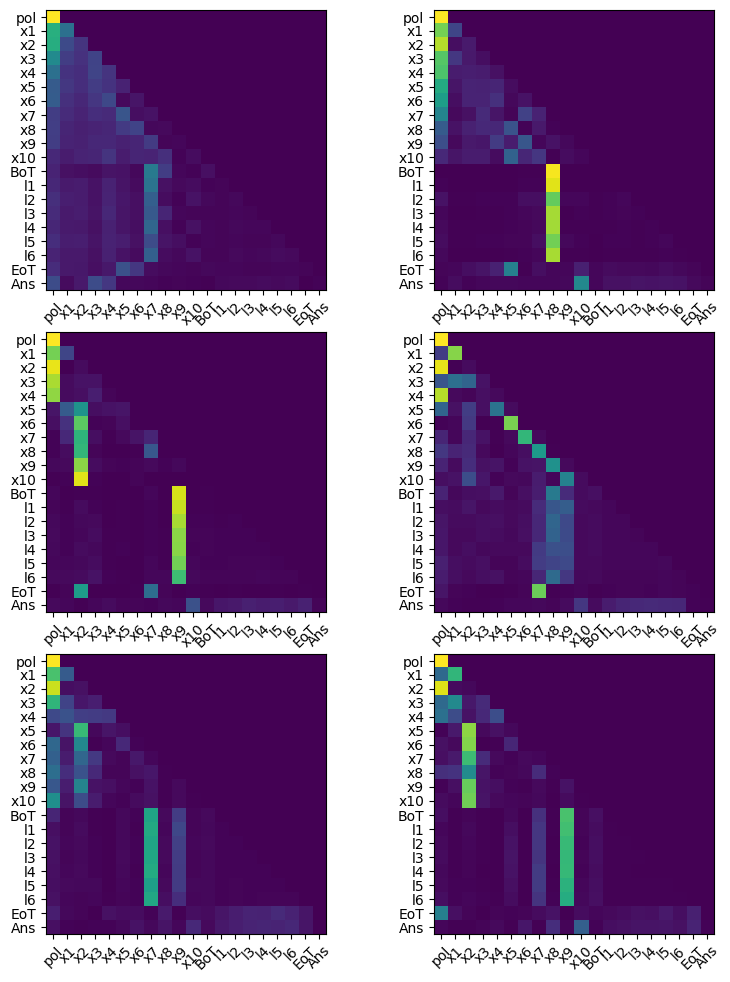

In [ ]:
seq_len = total_seqs

save_figures = True 

# Collect all attention data for all layers first
all_layers_data = []
for i in range(num_layers):
    encoder_avg_attn = test_interp_dict[seq_len-1]['encoder_output']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    latent0_avg_attn = test_interp_dict[seq_len-1]['latent_output_0']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    latent1_avg_attn = test_interp_dict[seq_len-1]['latent_output_1']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    latent2_avg_attn = test_interp_dict[seq_len-1]['latent_output_2']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    latent3_avg_attn = test_interp_dict[seq_len-1]['latent_output_3']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    latent4_avg_attn = test_interp_dict[seq_len-1]['latent_output_4']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    latent5_avg_attn = test_interp_dict[seq_len-1]['latent_output_5']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 
    decoder_avg_attn = test_interp_dict[seq_len-1]['decoder_output']['hidden_states'][f'blocks.{i}.attn.hook_pattern'].mean(dim=0).cpu().numpy() 

    encoder_seq_len = encoder_avg_attn.shape[1]

    # Use num_heads for padding instead of hardcoded 2
    encoder_avg_attn = torch.concatenate([torch.tensor(encoder_avg_attn), torch.zeros(num_heads, encoder_seq_len, 8)], dim=2)
    latent0_avg_attn = torch.concatenate([torch.tensor(latent0_avg_attn), torch.zeros(num_heads, 1, 7)], dim=2)
    latent1_avg_attn = torch.concatenate([torch.tensor(latent1_avg_attn), torch.zeros(num_heads, 1, 6)], dim=2)
    latent2_avg_attn = torch.concatenate([torch.tensor(latent2_avg_attn), torch.zeros(num_heads, 1, 5)], dim=2)
    latent3_avg_attn = torch.concatenate([torch.tensor(latent3_avg_attn), torch.zeros(num_heads, 1, 4)], dim=2)
    latent4_avg_attn = torch.concatenate([torch.tensor(latent4_avg_attn), torch.zeros(num_heads, 1, 3)], dim=2)
    latent5_avg_attn = torch.concatenate([torch.tensor(latent5_avg_attn), torch.zeros(num_heads, 1, 2)], dim=2)

    decoder_avg_attn = torch.tensor(decoder_avg_attn[:, 0:2, :(10+total_seqs)]) # extra 10 means [pol] + [BoT] + [EoT] + [Ans] + 6 latent steps 
    all_avg_attn = torch.concatenate([encoder_avg_attn, latent0_avg_attn, latent1_avg_attn, latent2_avg_attn, latent3_avg_attn, latent4_avg_attn, latent5_avg_attn, decoder_avg_attn], dim=1)
    
    all_layers_data.append(all_avg_attn)

# Compute global color limits across all layers and heads
all_head_data = []
for layer_data in all_layers_data:
    for head_idx in range(num_heads):
        A_head = layer_data[head_idx]
        if isinstance(A_head, torch.Tensor):
            A_head = A_head.detach().cpu().numpy()
        all_head_data.append(A_head)

vmin = min(A.min() for A in all_head_data)
vmax = max(A.max() for A in all_head_data)
print(vmin, vmax)

# Create single figure with layout: rows = layers, cols = heads
nrows = num_layers
ncols = num_heads
fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols/2, 4*nrows), gridspec_kw={'hspace': 0.15, 'wspace': 0.0})

# Handle case where axes is not 2D array
if num_layers == 1 and num_heads == 1:
    axes = np.array([[axes]])
elif num_layers == 1:
    axes = axes.reshape(1, -1)
elif num_heads == 1:
    axes = axes.reshape(-1, 1)

tick_labels = ['pol'] + [f'x{i}' for i in range(1, seq_len+1)] + ['BoT'] + [f'l{i}' for i in range(1, 7)] + ['EoT', 'Ans'] 

# Plot all layers and heads
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        ax = axes[layer_idx, head_idx]
        
        A_head = all_layers_data[layer_idx][head_idx]
        if isinstance(A_head, torch.Tensor):
            A_head = A_head.detach().cpu().numpy()
        
        im = ax.imshow(A_head[(total_seqs - 2) - (seq_len - 2):, (total_seqs - 2) - (seq_len - 2):], aspect="equal", vmin=vmin, vmax=vmax)
        
        ax.set_xticks([j for j in range(len(tick_labels))])  
        ax.set_xticklabels(tick_labels, rotation=45)
        ax.set_yticks([j for j in range(len(tick_labels))])
        ax.set_yticklabels(tick_labels)

if save_figures: 
    save_dir = f'figures/layers_{num_layers}/heads_{num_heads}/seq_{seq_len}/mod_{polynomial_mod}/attn/' 
    if not os.path.exists(save_dir): 
        os.makedirs(save_dir)
    fig.savefig(f'{save_dir}/attn_all_layers.pdf', dpi=300, bbox_inches='tight')

plt.show()